# Implementacja zaawansowanych metod analizy tekstu w Pythonie

## Przygotowanie danych

In [32]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

# newsgroups = fetch_20newsgroups(subset='all')
# print(newsgroups.target_names)
categories =['sci.med', 'sci.space']
data = fetch_20newsgroups( subset = 'train' , categories =categories, remove =( 'headers','footers','quotes'))
texts = data.data
labels = data.target

print(f"Pomyślnie załadowano {len(texts)} dokumentów.")
print(f"Klasa 0: {categories[0]} (Medycyna), Klasa 1: {categories[1]} (Kosmos)")

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', token_pattern=r'(?u)\b[a-zA-Z]{3,}\b')
tfidf_matrix = vectorizer.fit_transform(texts)
print(f"Rozmiar macierzy TF-IDF: {tfidf_matrix.shape} (Dokumenty x Słowa kluczowe)")
print(tfidf_matrix.toarray())


# Lista słów odpowiadających kolumnom macierzy
feature_names = vectorizer.get_feature_names_out()

# Wyświetlenie słów i ich indeksów (czyli numeru kolumny w tfidf_matrix)
for idx, word in enumerate(feature_names):
    print(f"{idx}: {word}")

Pomyślnie załadowano 1187 dokumentów.
Klasa 0: sci.med (Medycyna), Klasa 1: sci.space (Kosmos)
Rozmiar macierzy TF-IDF: (1187, 1000) (Dokumenty x Słowa kluczowe)
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.05146981 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
0: able
1: accepted
2: access
3: according
4: acid
5: act
6: active
7: activities
8: activity
9: actually
10: add
11: added
12: addition
13: additional
14: address
15: administration
16: adults
17: advanced
18: advertising
19: advice
20: aerospace
21: age
22: agency
23: ago
24: agree
25: aids
26: air
27: aircraft
28: allen
29: allergic
30: allow
31: alternative
32: altitude
33: american
34: 

## Word2Vec — Gensim

In [3]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.5 MB/s eta 0:00:00


In [33]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

# sentences = [text.lower().split() for text in texts]
# model = Word2Vec(sentences, vector_size=50, window=5, min_count=1)
# print(model.wv['kot'])

sentences = [word_tokenize(doc.lower()) for doc in texts ]
model = Word2Vec(sentences, vector_size =100, window =5, min_count =5)

print(model.wv.similarity('space', 'nasa'))
print(model.wv.similarity('doctor', 'hospital'))
print(model.wv.most_similar('disease') )

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


0.929926
0.69618016
[('treatment', 0.9926300644874573), ('scientific', 0.9923522472381592), ('evidence', 0.9913114309310913), ('inflammation', 0.990467369556427), ('results', 0.9903768301010132), ('important', 0.9898709058761597), ('made', 0.9894561767578125), ('died', 0.9892148971557617), ('researchers', 0.9892023205757141), ('net', 0.9891378283500671)]


## Analiza tematyczna — LDA

In [35]:
from gensim.corpora.dictionary import Dictionary
from gensim.models.ldamodel import LdaModel
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

sentences_clean = []
for s in sentences:
    clean_tokens = [word for word in s if word.isalpha() and len(word) > 2 and word not in stop_words]
    sentences_clean.append(clean_tokens)

sentences = [s for s in sentences_clean if len(s)>5]

# Tworzymy słownik z unikalnych słów w korpusie
dictionary = Dictionary(sentences)

# Przekształcamy dokumenty na reprezentację bag-of-words
corpus = [dictionary.doc2bow(s) for s in sentences]

# Trenujemy model LDA z 2 tematami
lda = LdaModel(corpus, num_topics=2, id2word=dictionary, passes=10)

# Wyświetlamy opis każdego tematu
for idx, topic in lda.print_topics():
    print(f"Temat {idx}: {topic}")

Temat 0: 0.010*"space" + 0.004*"nasa" + 0.004*"use" + 0.003*"launch" + 0.003*"information" + 0.003*"new" + 0.003*"data" + 0.003*"satellite" + 0.003*"health" + 0.003*"available"
Temat 1: 0.005*"just" + 0.005*"like" + 0.004*"people" + 0.004*"think" + 0.003*"know" + 0.003*"time" + 0.003*"space" + 0.003*"does" + 0.003*"did" + 0.003*"good"


## Redukcja wymiarowości — SVD

[[ 0.16726078  0.07232985]
 [ 0.54250729  0.54230197]
 [ 0.15707232 -0.03744921]
 ...
 [ 0.12411698 -0.11290164]
 [ 0.09785951 -0.00140805]
 [ 0.11339275 -0.07628252]]


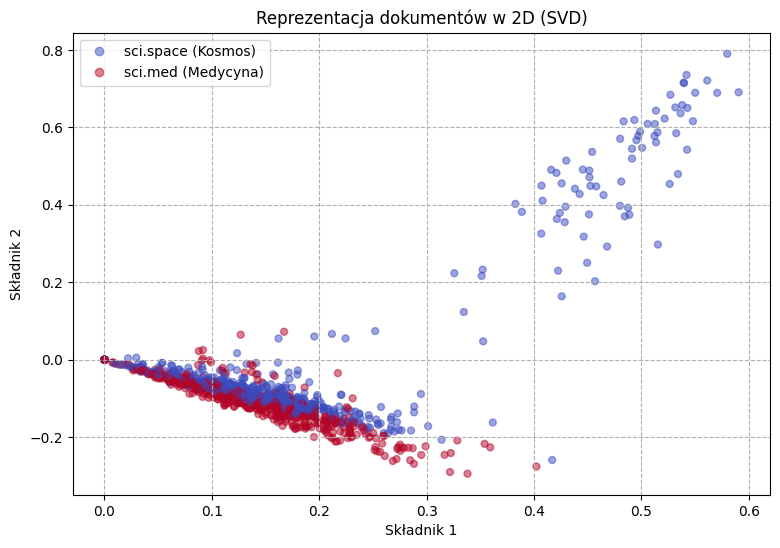

In [43]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(tfidf_matrix)
print(X_2d)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, alpha=0.5, cmap='coolwarm', s=25)
plt.title("Reprezentacja dokumentów w 2D (SVD)")
plt.xlabel("Składnik 1")
plt.ylabel("Składnik 2")
plt.legend(handles=scatter.legend_elements()[0], labels=['sci.space (Kosmos)','sci.med (Medycyna)'])
plt.grid(True, linestyle='--')
plt.show()